# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">

This Exploratory Data Analysis (EDA) project analyzes a comprehensive US Real Estate dataset scraped from Realtor.com, containing over 2.2 million listing records across 10 key features. The primary focus is to examine the economic and physical factors driving real estate listing prices across different US states, cities, and zip codes. By applying data auditing, cleaning, and descriptive visualization techniques, this study aims to resolve data quality challenges like heavy skewness and missing values, while unearthing key market patterns to inform future predictive modeling and real estate insights.


</div>

# OBJECTIVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">

<ul>
<li>Data Preprocessing: Clean the dataset by handling missing values, removing duplicates, filtering extreme outliers, and reformatting date/categorical fields.

<li>Univariate Analysis: Evaluate the overall distribution, skewness, and central tendencies of key numerical features such as price, house_size, and acre_lot.

<li>Geographical Insights: Analyze price variations and price-per-square-foot trends across different states, cities, and zip codes to identify high-value versus affordable markets.

<li>Correlation & Relationship Mapping: Determine the strength of relationships between physical property features (bedrooms, bathrooms, living area) and final listing prices.

<li>Temporal Trend Analysis: Explore historical market behavior using prev_sold_date to observe sales activity patterns over time.

<li>Feature Engineering: Create derived metrics like price_per_sqft and total_rooms to prepare a clean, structured baseline for future machine learning models.

</div>

<div
>

# 1. Collection & Inspection


## 1.1 Loading Libraries and Dataset

In [1]:
import numpy as np
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_parquet('/home/kartika/Datasets/brazilianolist.csv', engine='pyarrow')

for col in data.select_dtypes(include = ['object']).columns :
    data[col] = data[col].astype('category')

for col in data.select_dtypes(include = ['int', 'float']).columns :
    data[col] = pd.to_numeric(data[col], downcast = 'integer' if 'int' in str(data[col].dtype) else 'float')



print(f"Memory Usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Memory Usage: 108.87 MB


In [3]:
def out_per(col = None, df = None):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    per = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)]) / len(df) * 100
    high = len(df[df[col] > upper_bound])/ len(df) * 100
    low = len(df[df[col] < lower_bound])/ len(df) * 100
    print(f"Percentage of outliers in {col}: {per:.2f}%")
    print(f"Percentage of Extreme High Outliers in {col}: {high:.2f}%")
    print(f"Percentage of Extreme Low Outliers in {col}: {low:.2f}%")

<div>

<div>

## 1.2 Basic Inspection

In [4]:
data.head(5)


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype   
---  ------          -----   
 0   brokered_by     float32 
 1   status          category
 2   price           float64 
 3   bed             float32 
 4   bath            float32 
 5   acre_lot        float64 
 6   street          float32 
 7   city            category
 8   state           category
 9   zip_code        float32 
 10  house_size      float64 
 11  prev_sold_date  category
dtypes: category(4), float32(5), float64(3)
memory usage: 107.4 MB


In [6]:
data.isnull().sum()

brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64

In [7]:
(data.isnull().sum()/len(data))*100

brokered_by        0.203604
status             0.000000
price              0.069215
bed               21.618797
bath              22.986666
acre_lot          14.624130
street             0.488056
city               0.063197
state              0.000359
zip_code           0.013430
house_size        25.533983
prev_sold_date    32.981627
dtype: float64

In [8]:
data.duplicated().sum()

np.int64(0)

<div>

# 2. Cleaning & Wrangling

## 2.1 Dropping Irrelevant Fields

In [9]:
data.drop(columns = ['brokered_by', 'street'], inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"> 'brokered_by' and 'street' are removed as irrelevant field. 

In [10]:
data.dropna(subset = ['city', 'state', 'zip_code'], inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">< 0.01% values are missing, so dropped them.

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Dropping irrelevant rows or fields and duplicates are done before splitting data.

In [11]:
data['prev_sold_date'] = pd.to_datetime(data['prev_sold_date'], errors = 'coerce')
## errors = coerce, valid date --> converted to datetime,
## null/Nan --> remains Nan


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
Also converted prev_sold_date to datetime, preserving the null values.

<div>

## 2.2 Train-Test-Validate Split

In [12]:
train, temp = train_test_split(data, test_size = 0.4, random_state = 42)
validate, test = train_test_split(temp, test_size = 0.5, random_state = 42)


print(f"Train: {len(train)}, {len(train)/len(data)*100}%\n Validate: {len(validate)},{len(validate)/len(data)*100}% \n Test: {len(test)}, {len(test)/len(data)*100}%")

Train: 1334866, 59.999991010334966%
 Validate: 444955,19.999982020669936% 
 Test: 444956, 20.000026968995094%


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Splitted original data into train, test, validate (60/20/20) prior to data pre-processing and feature engineering to prevent data leakage.

<div>

## 2.3 Handaling Missing Values(Imputation)

In [13]:
city_price_median = train.groupby('city', observed = True)['price'].transform('median')
state_price_median = train.groupby('state', observed = True)['price'].transform('median')
global_price_median = train['price'].median()

#To prevent Data Leakage
for df in [train, test, validate]:
    df['price'] = df['price'].fillna(df['city'].map(city_price_median))
    df['price'] = df['price'].fillna(df['state'].map(state_price_median))
    df['price'] = df['price'].fillna(global_price_median)



In [14]:
#train['price'].isnull().sum()
#validate['price'].isnull().sum()
#test['price'].isnull().sum()

In [ ]:
train.loc[train['price'].idxmax()] ## Drop

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"><1% values are missing in price field, so imputed with group median.

<div>

In [15]:
city_acre_lot_median = train.groupby('city', observed = True)['acre_lot'].transform('median')
state_acre_lot_median = train.groupby('state', observed = True)['acre_lot'].transform('median')
global_acre_lot_median = train['acre_lot'].median()

for df in [train, test, validate]:
    df['acre_lot'] = df['acre_lot'].fillna(df['city'].map(city_acre_lot_median))
    df['acre_lot'] = df['acre_lot'].fillna(df['state'].map(state_acre_lot_median))
    df['acre_lot'] = df['acre_lot'].fillna(global_acre_lot_median)

In [16]:
#train['acre_lot'].isnull().sum()
#validate['acre_lot'].isnull().sum()
#test['acre_lot'].isnull().sum()




<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Around 15% values are missing in acre_lot, so imputed with group median.

<div>

In [17]:
bins = list(range(0, 10000, 500)) + [np.inf]
train['sqft_bin'] = pd.cut(train['house_size'], bins=bins)
test['sqft_bin'] = pd.cut(train['house_size'], bins=bins)
validate['sqft_bin'] = pd.cut(train['house_size'], bins=bins)


sqft_bin_median = train.groupby('sqft_bin', observed = True)['bed'].transform('median')
global_bed_median = train['bed'].median()
global_bath_median = train['bath'].median()

for df in [train, test, validate]:
    df['bed'] = df['bed'].fillna(df['sqft_bin'].map(sqft_bin_median))
    df['bed'] = df['bed'].fillna(global_bed_median)


for df in [train, test, validate]:
    df['bath'] = df['bath'].fillna(df['sqft_bin'].map(sqft_bin_median))
    df['bath'] = df['bath'].fillna(global_bath_median)


In [18]:
#train['bed'].isnull().sum()
#validate['bath'].isnull().sum()
#test['bed'].isnull().sum()

In [19]:
train.drop('sqft_bin', axis = 1, inplace = True)

In [20]:
validate.drop('sqft_bin', axis = 1, inplace = True)

In [21]:
test.drop('sqft_bin', axis = 1, inplace = True)

In [52]:
def flag_bed(df, sqft_col = 'house_size', bed_col = 'bed', min_ratio = 120):
    ratio = df[sqft_col] /df[bed_col]
    keep = ratio >=min_ratio

    dropped_ids = df.index[~keep]
    print(f"Dropped {len(dropped_ids)} rows: {list(dropped_ids)}")
    return df[keep].copy()


train = flag_bed(train)
test = flag_bed(test)
validate = flag_bed(validate)

Dropped 0 rows: []


Dropped 0 rows: []
Dropped 0 rows: []


In [53]:
def flag_bed(df, sqft_col = 'house_size', bed_col = 'bath', min_ratio = 40):
    ratio = df[sqft_col] /df[bed_col]
    keep = ratio >=min_ratio

    dropped_ids = df.index[~keep]
    print(f"Dropped {len(dropped_ids)} rows: {list(dropped_ids)}")
    return df[keep].copy()


train = flag_bed(train)
test = flag_bed(test)
validate = flag_bed(validate)

Dropped 6 rows: [1491853, 2011284, 568278, 1156036, 1747654, 1363429]
Dropped 3 rows: [863531, 1794285, 406577]
Dropped 1 rows: [1162423]


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">~22% values are missing in bed and ~23% values are missing in bath, so imputed with house_size(sqft_bins). Dropped sqft_bin after imputation.
<br>Dropped invalid rows, where house size to bed ratio was <120, which is non standard for typical houses or apartments.
<br> DRopped invalid rows, where house size to bath ratio was < 40, which is non standard for typical houses or apartments.

<div>

In [22]:
group_median = train.groupby(['zip_code', 'bed', 'bath'], observed=True)['house_size'].transform('median')
global_group_median = train['house_size'].median()

for df in [train, test, validate]:
    df['house_size'] = df['house_size'].fillna(df['house_size'].map(sqft_bin_median))
    df['house_size'] = df['house_size'].fillna(global_group_median)



In [23]:
#train['house_size'].isnull().sum()
#validate.house_size.isnull().sum()
#test['house_size'].isnull().sum()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Around 25% values are missing in house_size, so imputed with group median from 'zip_code', 'bed', and 'bath'.

<div>

# 3. Exploratory Data Analysis

# 3.1 Univarite Analysis



## 3.1.1 Numerical Fields

In [24]:
train['price'].describe()

count    1.334866e+06
mean     5.232324e+05
std      1.538433e+06
min      0.000000e+00
25%      1.650000e+05
50%      3.250000e+05
75%      5.500000e+05
max      1.000000e+09
Name: price, dtype: float64

In [25]:
train['price'].skew()

np.float64(229.63841473269775)

In [26]:
out_per('price', train)


Percentage of outliers in price: 7.72%
Percentage of Extreme High Outliers in price: 7.72%
Percentage of Extreme Low Outliers in price: 0.00%


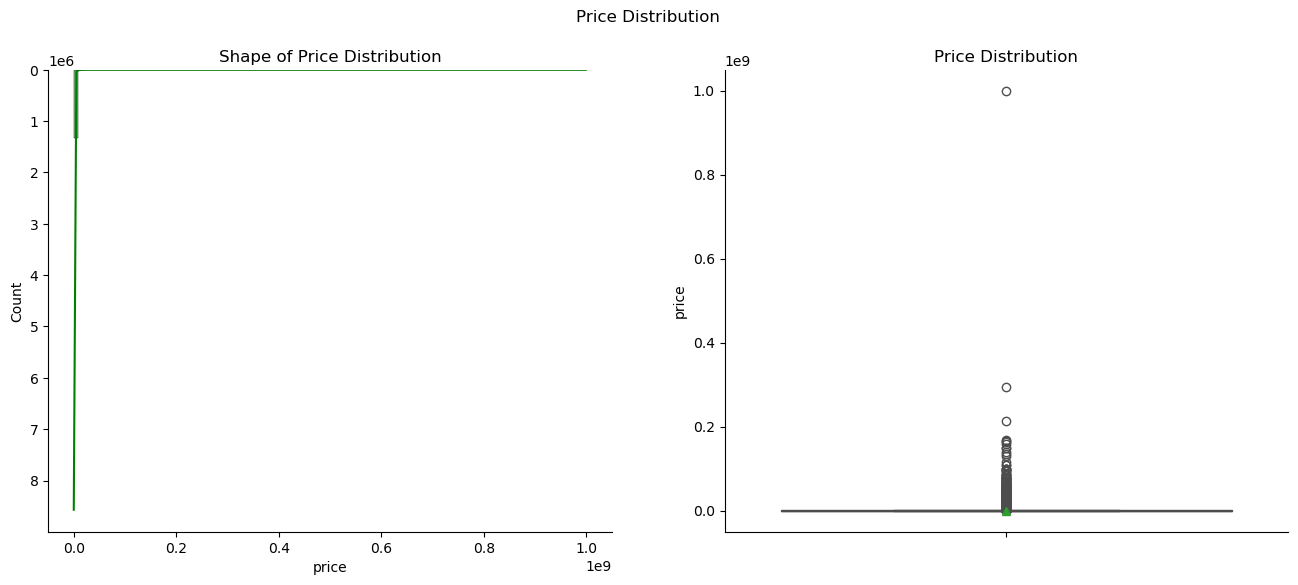

In [27]:
fig, ax = plt.subplots(1, 2, figsize = (16,6))

sns.histplot(
    x = train['price'],
    bins = 120,
    kde = True,
    color = 'green',
    ax = ax[0],

)
ax[0].set_title('Shape of Price Distribution')
ax[0].invert_yaxis()

sns.boxplot(
    data = train,
    y = 'price',
    color = 'blue',
    showmeans = True,
    ax = ax[1]
)
ax[1].set_title('Price Distribution')


plt.suptitle('Price Distribution')
sns.despine()
plt.show()

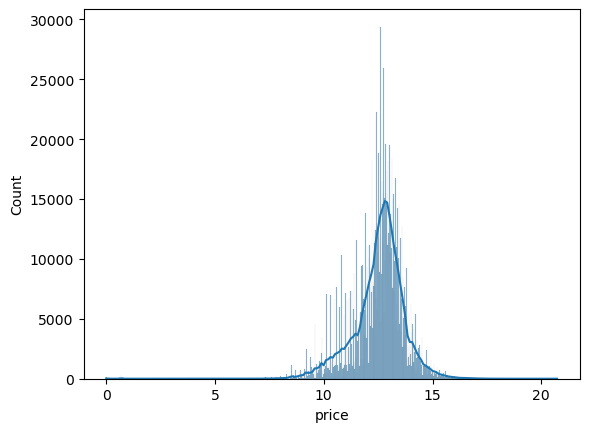

In [54]:
sns.histplot(
    np.log1p(train['price']),
    kde = True
)

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the houses have mid-range to budget price. The distribution is extremely positively skewed, with most the houses having price arond half million, while few houses priced extremely high(billions). The outliers are extremely high outliers, as the price of house in top 25% jumps to billion from million.

<div>

In [29]:
train['bed'].describe()

count    1.334866e+06
mean     3.216748e+00
std      1.465749e+00
min      1.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      4.730000e+02
Name: bed, dtype: float64

In [30]:
train['bath'].describe()

count    1.334866e+06
mean     2.382328e+00
std      1.432825e+00
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      8.300000e+02
Name: bath, dtype: float64

In [31]:
out_per('bath', train)

Percentage of outliers in bath: 3.54%
Percentage of Extreme High Outliers in bath: 3.54%
Percentage of Extreme Low Outliers in bath: 0.00%


In [32]:
out_per('bed', train)

Percentage of outliers in bed: 5.35%
Percentage of Extreme High Outliers in bed: 2.42%
Percentage of Extreme Low Outliers in bed: 2.94%


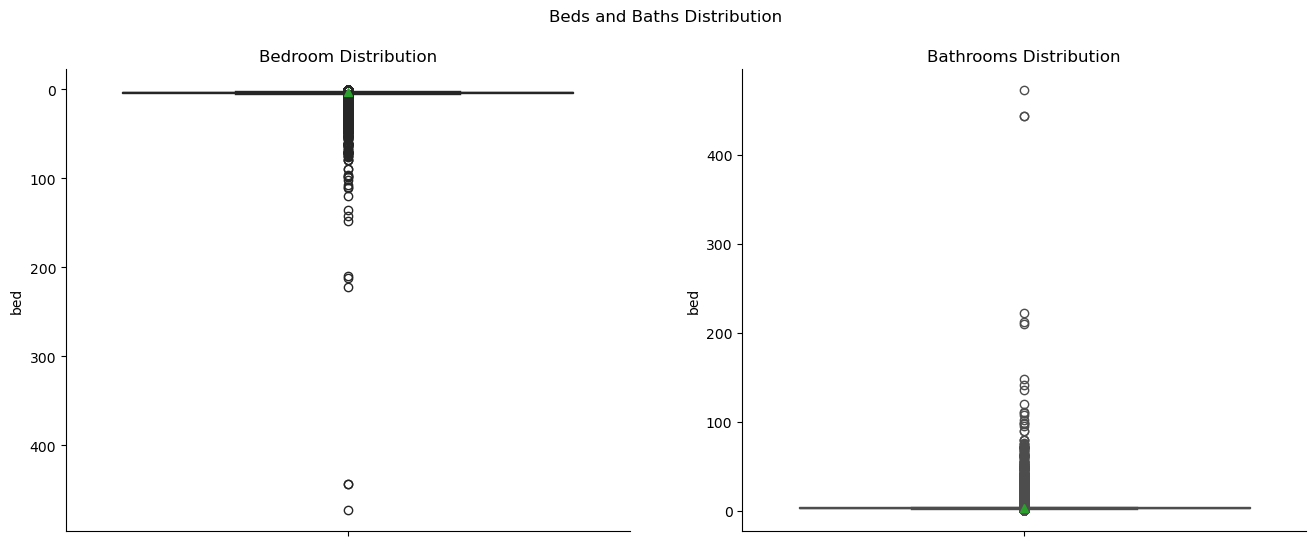

In [33]:
fig, ax = plt.subplots(1, 2, figsize = (16,6))

sns.boxplot(
    y = train['bed'],
    showmeans = True,
    color = 'green',
    ax = ax[0],

)
ax[0].set_title('Bedroom Distribution')
ax[0].invert_yaxis()

sns.boxplot(
    y = train['bed'],
    showmeans = True,
    color = 'blue',
    ax = ax[1]
)
ax[1].set_title('Bathrooms Distribution')


plt.suptitle('Beds and Baths Distribution')
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
The bathroom distribution among house property is extremely positively skewed, majority of housese have 1-2 bedrooms, while rest have large number of bathrooms.
<br>
The bedroom distribution among house property is extremely positively skewed, majority of housese have 1-4 bedrooms, while rest have extremely large number of bedrooms. The bedroom skewness is different from bathrooms, as some houses have low numbers of bedrooms compared to central value. Hence, in bedroom there is presence of both extreme high and low outliers.

<div>

In [34]:
train['acre_lot'].describe()

count    1.334866e+06
mean     1.294359e+01
std      6.986545e+02
min      0.000000e+00
25%      1.700000e-01
50%      2.600000e-01
75%      6.800000e-01
max      1.000000e+05
Name: acre_lot, dtype: float64

In [35]:
train['house_size'].describe()

count    1.334866e+06
mean     2.008727e+03
std      1.256111e+04
min      4.000000e+00
25%      1.456000e+03
50%      1.760000e+03
75%      2.141000e+03
max      9.842382e+06
Name: house_size, dtype: float64

In [36]:
train['acre_lot'].skew()

np.float64(115.80489425854077)

In [37]:
train['house_size'].skew()

np.float64(591.4480662944538)

In [38]:
out_per('acre_lot', train)

Percentage of outliers in acre_lot: 16.48%
Percentage of Extreme High Outliers in acre_lot: 16.48%
Percentage of Extreme Low Outliers in acre_lot: 0.00%


In [39]:
out_per('house_size', train)

Percentage of outliers in house_size: 8.53%
Percentage of Extreme High Outliers in house_size: 8.34%
Percentage of Extreme Low Outliers in house_size: 0.19%


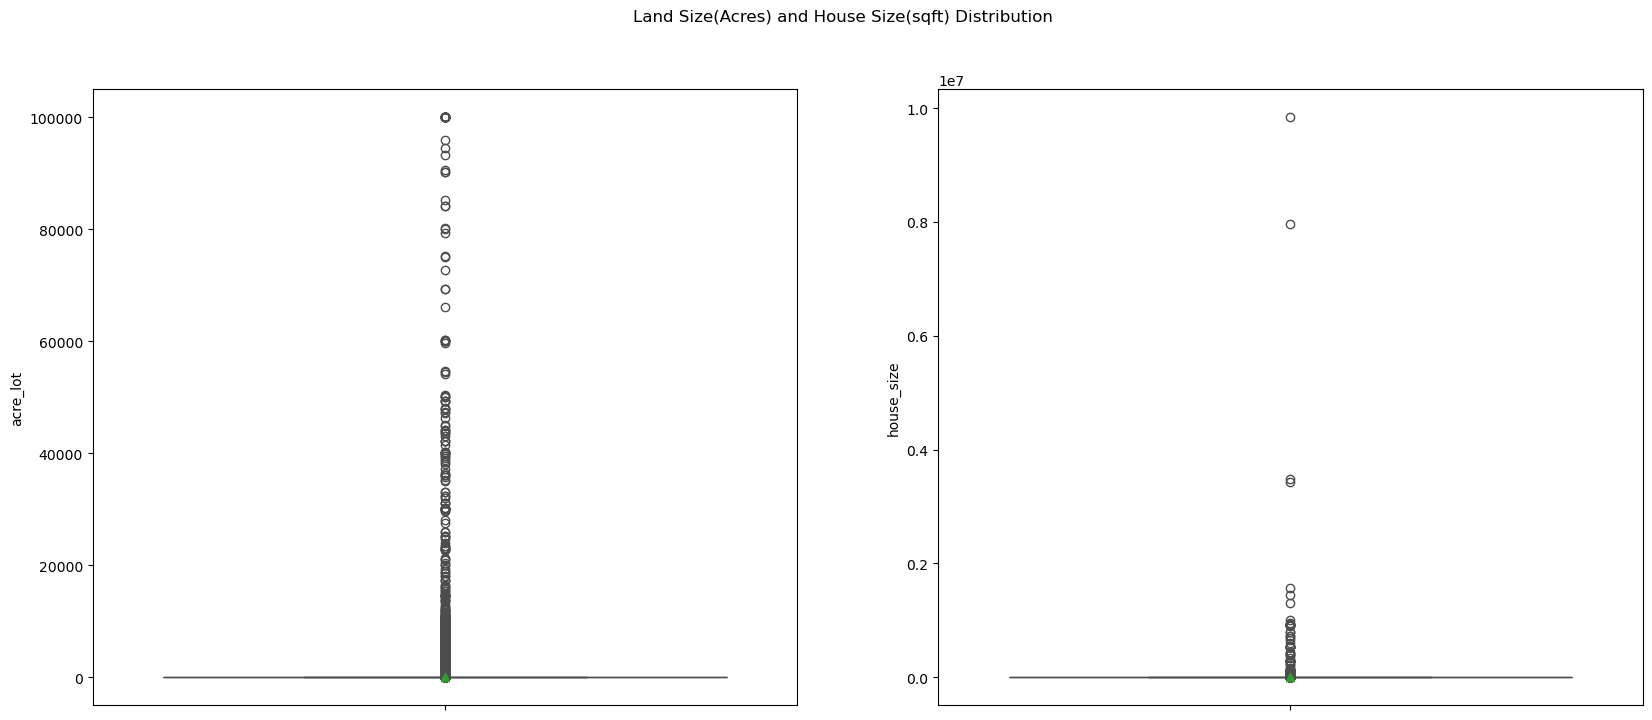

In [40]:
fig, ax = plt.subplots(1,2, figsize = (20,8))

sns.boxplot(
    data = train,
    y = 'acre_lot',
    color = 'blue',
    showmeans= True,
    ax = ax[0]
)

sns.boxplot(
    data = train, 
    y = 'house_size',
    color = 'cyan',
    showmeans = True,
    ax = ax[1]
    
)

plt.suptitle('Land Size(Acres) and House Size(sqft) Distribution')
plt.show()



<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
The land size distribution is extremely positivley skewed. Majority of land size is less than or equal to 0.75 acres, while rest properties have extremely large land size.
<br>The house size is also extremely positively skewed. The house size distribution contains both extremely high and low outliers, will be handled during data preprocessing.

<divv>

## 3.1.2 Categorical Fields

In [41]:
train['status'].value_counts()

status
for_sale          832737
sold              487187
ready_to_build     14942
Name: count, dtype: int64

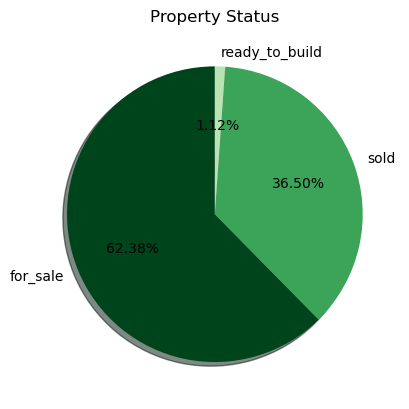

In [42]:
plt.pie(
    train['status'].value_counts().values,
    labels = train['status'].value_counts().index,
    autopct = '%1.2f%%',
    shadow = True,
    startangle = 90,
    colors = plt.cm.Greens(np.linspace(1, 0.3, 3))
)

plt.title('Property Status')
sns.despine()
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">62.38% of the property have already built house, which are ready for sale. 36.5% of the property houses have been already sold and rest less than 2% of the property represent vacant land ready for construction.

<div>

In [43]:
train['city'] = train['city'].cat.remove_unused_categories()
train['city'].value_counts()

city
Houston              14388
Chicago              10991
New York City         7641
Jacksonville          7028
Philadelphia          6272
                     ...  
Adams Street             1
Plush                    1
178th Ave Wabasha        1
Zoe                      1
Zoarville                1
Name: count, Length: 18663, dtype: int64

In [44]:
top_cities = train['city'].value_counts().head(10)
top_cities_sum = top_cities.sum()
top_cities_pct = (top_cities_sum/len(train))*100
top_cities_pct

np.float64(5.465792072013221)

In [45]:
train['state'] = train['state'].cat.remove_unused_categories()
train['state'].value_counts()

state
Florida                 149193
California              135971
Texas                   125276
New York                 61869
North Carolina           51364
Illinois                 51011
Georgia                  48535
Pennsylvania             46737
Arizona                  43532
Virginia                 41350
Washington               37430
Ohio                     35566
New Jersey               29041
Maryland                 27499
Missouri                 27032
Minnesota                26129
Michigan                 25526
South Carolina           25432
Wisconsin                25374
Tennessee                24517
Massachusetts            22870
Oklahoma                 22369
Alabama                  20440
Colorado                 19366
Oregon                   19283
Kentucky                 15981
Louisiana                15491
Iowa                     13902
Arkansas                 13803
New Mexico               12671
Indiana                  11257
Idaho                     9904
Mi

In [46]:
len(train['state'].value_counts())

54

In [47]:
top_states = train['state'].value_counts().head(10)
top_states_sum = top_states.sum()
top_states_pct = (top_states_sum/len(train))*100
top_states_pct

np.float64(56.54784824843841)

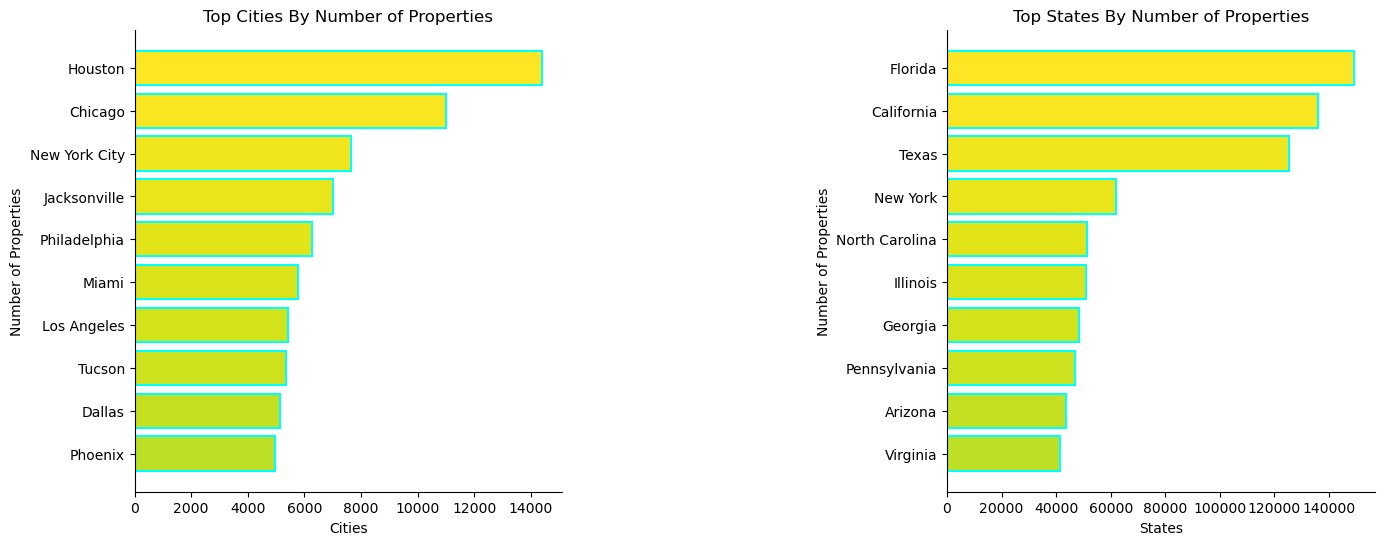

In [48]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))

ax[0].barh(
    y = train['city'].value_counts().head(10).index,
    width = train['city'].value_counts().head(10).values,
    color = plt.cm.viridis(np.linspace(1, 0.9, 10 )),
    linewidth = 1.5,
    edgecolor = 'cyan'
)
ax[0].set_title('Top Cities By Number of Properties')
ax[0].set_ylabel('Number of Properties')
ax[0].set_xlabel('Cities')
ax[0].invert_yaxis()



ax[1].barh(
    y = train['state'].value_counts().head(10).index,
    width = train['state'].value_counts().head(10).values,
    color = plt.cm.viridis(np.linspace(1, 0.9, 10 )),
    linewidth = 1.5,
    edgecolor = 'cyan'
)
ax[1].set_title('Top States By Number of Properties')
ax[1].set_ylabel('Number of Properties')
ax[1].set_xlabel('States')
ax[1].invert_yaxis()



plt.subplots_adjust(wspace = 0.9)
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Houston, Chicago and New York City are top three cities by number of property. Florida, California and Texas are top three states by number of properties.
<li>Also, around 56% of the properties come from top 10 states, while only 5.6% of the properties come from top 10 cities.
<li>This indicates city-level distribution is highly spread out, while state-level distribution is much more concentrated.
<li>State is a much more dominant geographic feature than city.
</ul>
</div>

<div>

# 3.2 Bivariate Analysis

## 3.2.1 Target vs Numerical

In [52]:
train['bed'].corr(train['price'])

np.float64(0.13921711224974195)

In [54]:
train['bath'].corr(train['price'])

np.float64(0.236904652036416)

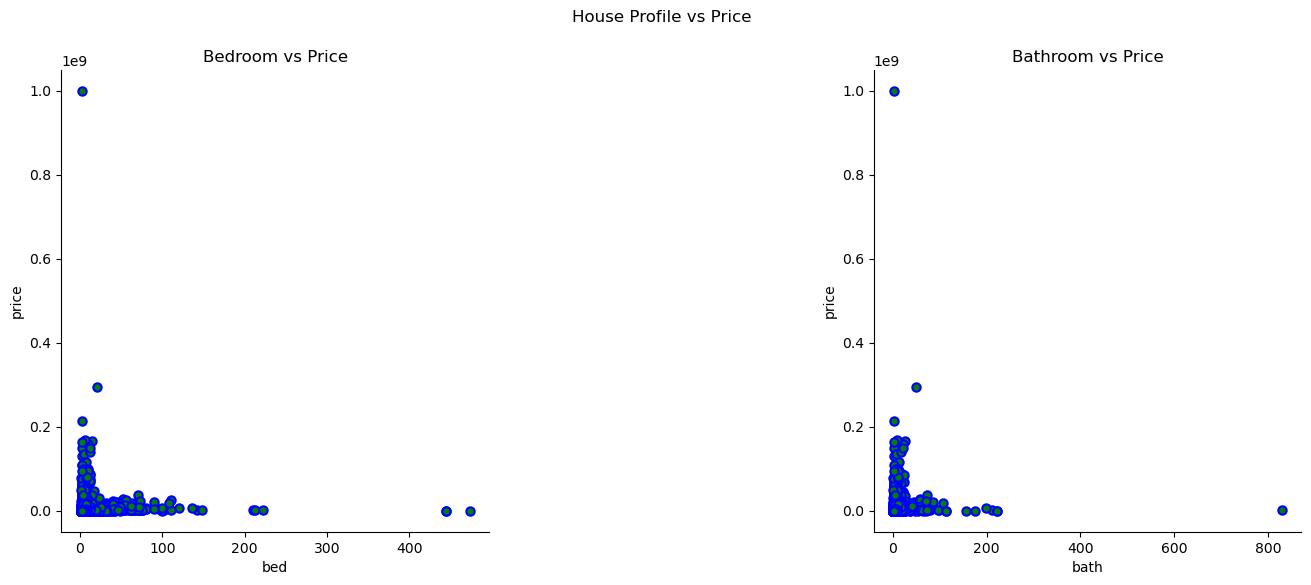

In [60]:
fig, ax = plt.subplots(1, 2, figsize = (16,6))


# Bedroom vs Price
sns.scatterplot(
    data = train,
    x = 'bed',
    y = 'price',
    color = 'green',
    linewidth = 1.5,
    edgecolor = 'blue',
    ax = ax[0],
)
ax[0].set_title('Bedroom vs Price')

# Bathroom vs Price
sns.scatterplot(
    data = train,
    x = 'bath',
    y = 'price',
    linewidth = 1.5,
    edgecolor = 'blue',
    color = 'green',
    ax = ax[1],
)
ax[1].set_title('Bathroom vs Price')


plt.suptitle('House Profile vs Price')
plt.subplots_adjust(wspace = 0.9)
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is very weak(negligible) correlation between the number of bedrooms and price of the property. The data the highly skewed so the relation is distorted. 

<div>

<div>

<div>

In [ ]:
print(f"Skewness of House Size : {data['house_size'].skew()}")
print(f"Skewness of Acre lot: {data['acre_lot'].skew()}")
print(f"Correlation of House Size and Price: {data['house_size'].corr(data['price'])}")
print(f"Correlation of Acre Lot and Price: {data['acre_lot'].corr(data['price'])}")

Skewness of House Size : 1491.294813493341
Skewness of Acre lot: 114.99914055428152
Correlation of House Size and Price: 0.00027541960679741776
Correlation of Acre Lot and Price: 0.014925752209494773


In [ ]:
out_per('house_size', data)

Percentage of outliers in house_size: 6.71%


In [ ]:
out_per('acre_lot', data)

Percentage of outliers in acre_lot: 15.73%


In [ ]:






# sns.lineplot(
#     data = data.sample(30000),
#     x = 'house_size',
#     y = 'price',
#     color = 'cyan',
#     markerfacecolor = 'green',
#     ax = ax[1][0],
# )
# ax[1][0].set_title('House size vs Price')



# sns.lineplot(
#     data = data.sample(30000),
#     x = 'acre_lot',
#     y = 'price',
#     color = 'cyan',
#     markerfacecolor = 'green',
#     ax = ax[1][1],
# )
# ax[1][1].set_title('Acre Lot vs Price')

# plt.suptitle('Property Size Profile')
# sns.despine()
# plt.subplots_adjust(wspace = 0.9)
# plt.tight_layout()
# plt.show()





<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is a extremely weak positive correlation between house size or acre plot with price of the property.

<div>

<div>

## 3.3 Location vs Price

In [ ]:
data['city'].value_counts()

city
Houston                      23862
Chicago                      18238
New York City                12634
Jacksonville                 11743
Philadelphia                 10449
                             ...  
4th Saint                        1
480th Saint                      1
30 31 Boardwalk Dr               1
3 Mi Southwest of Benteen        1
3 4 Highview Dr                  1
Name: count, Length: 20098, dtype: int64

In [ ]:
data['state'].value_counts()

state
Florida                 249432
California              227215
Texas                   208335
New York                103159
North Carolina           85745
Illinois                 85280
Georgia                  80977
Pennsylvania             78373
Arizona                  72825
Virginia                 68763
Washington               62461
Ohio                     59207
New Jersey               48199
Maryland                 46052
Missouri                 45145
Minnesota                43412
Michigan                 42429
Wisconsin                42390
South Carolina           42367
Tennessee                40964
Massachusetts            38041
Oklahoma                 37140
Alabama                  34053
Colorado                 32293
Oregon                   32163
Kentucky                 26316
Louisiana                25815
Arkansas                 23045
Iowa                     23033
New Mexico               21074
Indiana                  18840
Idaho                    16760
Mi

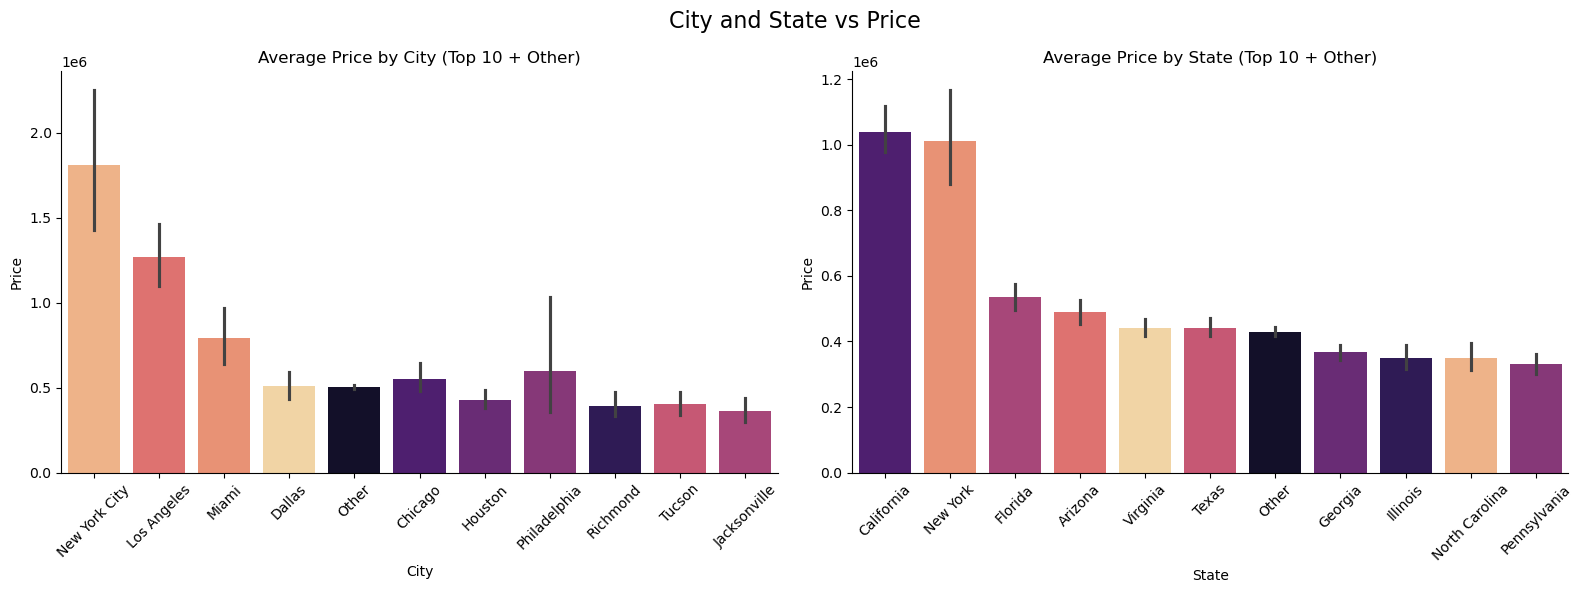

In [ ]:


fig, ax = plt.subplots(1, 2, figsize=(16, 6))


top_cities = data['city'].value_counts().nlargest(10).index

data['city_grouped'] = (
    data['city'].astype(str).where(data['city'].isin(top_cities), 'Other')
)

city_order = (
    data.groupby('city_grouped')['price']
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=data.sample(min(30000, len(data))),
    x='city_grouped',
    y='price',
    hue='city_grouped',
    order=city_order,
    palette='magma',
    ax=ax[0],
    legend=False,
)
ax[0].set_title('Average Price by City (Top 10 + Other)')
ax[0].set_xlabel('City')
ax[0].set_ylabel('Price')
ax[0].tick_params(axis='x', rotation=45)


top_states = data['state'].value_counts().nlargest(10).index


data['state_grouped'] = (
    data['state'].astype(str).where(data['state'].isin(top_states), 'Other')
)


state_order = (
    data.groupby('state_grouped')['price']
    .mean()
    .sort_values(ascending=False)
    .index
)


sns.barplot(
    data=data.sample(min(30000, len(data))),
    x='state_grouped',
    y='price',
    hue='state_grouped',
    order=state_order,
    palette='magma',
    ax=ax[1],
    legend=False,
)
ax[1].set_title('Average Price by State (Top 10 + Other)')
ax[1].set_xlabel('State')
ax[1].set_ylabel('Price')
ax[1].tick_params(axis='x', rotation=45)


plt.suptitle('City and State vs Price', fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Houston and Chicago are major city/state by number of properties.<br>
New York, Los Angeles and Miami are top three cities by highest average property pirce.<br>
California, New York and Florida are top three states by highest average property price.

<div>

<div>

# 5. Data Pre-Processing & Feature Engineering

<div>

## 5.4 Outliers Handaling
